# Car Accident Analysis — Weather, Climate & Population


Authors: Cameron Chen, Jessica Cole, Pantea Foroutan, Jennifer Kuei


### Introduction and Background 

In a car dominated society, driving has become the socially accepted norm for getting from place to place. The percentage of people in the US that own at least two cars has nearly tripled in the past 50 years. Despite the increasing capabilities of safety technology in motor vehicles, car crashes continue to cause significant injuries and fatalities. In 2023, an approximate of 40,901 individuals died in motor vehicle crashes. Furthermore, traffic accidents have a major economic impact through medical bills, insurance costs, and property damage, and the U.S. The Department of Transportation estimated $340 billion in economic costs in 2023.

<br>

While many factors contribute to traffic accident occurence and severity, weather conditions are known to be a contributing factor regarding how safe roads are. Conditions such as rain, fog, and snow can reduce visibility and create less friction on the road, which leads to a decrease in driving performance. Thus, it leads to an increase in the likelihood of accidents. Our project analyzes the situations regarding car accidents and to identify whether weather and climate conditions have an influence on the rate of traffic accidents in the United States, and how they vary between different regions.

<br><br>
<span style="color:red"> [INSERT PRIOR WORK] </span>


### Research Question 
How do weather conditions and population size affect traffic accident rates and patterns across different regions of the United States? <br>

### Hypothesis
We predict that in places where populations are higher and weather conditions are worse, accident rates will be higher. We also expect to see US regions with similar conditions will have similar weather-related crash patterns. By completetion of this project, we anticipate to better understand how weather and climate conditions are related to traffic accidents patterns across different regions of the United States. 

<br>

### Data 
The first dataset we’ll be using is recorded car accidents in the US over the past 8 years (US accidents 2016-2023). Our second dataset is nClimDiv which is a public climate weather dataset that describes weather conditions across the country(National Climate Divisional Database). Our third dataset describes the population of every US county (USA County Population Total). Below is the summary of the data along with the variables from each data set that we will be using to perform the analysis.

| Dataset | File Name | Variables to be used |
| -------- | -------- | -------- |
| USA County Population Total: 2016-2021 (Kaggle) | USA_County_Population.csv | county, 2016, 2017, 2018, 2019, 2020, 2021 |
| US accidents 2016-2023 (Kaggle) | accidents_200k.csv | Severity, Start_Time, Start_Lat, Start_Lng, County, State, Temperature(F), Humidity(%), Visibility(mi), Precipitation(in), Weather_Condition |
| NOAA Monthly U.S. Climate Divisional Database (NClimDiv) | us_accident_risk_weather_metrics.csv       |  State, Code, Region, Avg_Snowfall_Inches, Precip_Days_Per_Year, Freezing_Days_Per_Year, Dense_Fog_Days_Per_Year, Extreme_Rain_Days  |

<br>
All files are located in the data folder.

In [1]:
# 1. Setup (local / VS Code). Installs into the active kernel; run once.
%pip -q install pandas numpy matplotlib seaborn scipy statsmodels plotly kaleido kaggle
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, glob, os
import matplotlib.pyplot as plt, seaborn as sns
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
sns.set_theme(style="whitegrid"); os.makedirs("figs", exist_ok=True)
print("Setup OK")

Note: you may need to restart the kernel to use updated packages.
Setup OK


In [2]:
# 2. Download accidents dataset from Kaggle (local)
# ONE-TIME AUTH: place kaggle.json at  ~/.kaggle/kaggle.json  (mac/Linux)
#   or  C:\Users\<you>\.kaggle\kaggle.json  (Windows).
#   mac/Linux also run in a terminal:  chmod 600 ~/.kaggle/kaggle.json
# Get the token: kaggle.com -> profile -> Settings -> Create New API Token.
# Needs ~3 GB free disk. Downloads + unzips into ./data
import kaggle
kaggle.api.dataset_download_files("sobhanmoosavi/us-accidents", path="./data", unzip=True)
import glob; print(glob.glob("./data/*.csv"))

Dataset URL: https://www.kaggle.com/datasets/sobhanmoosavi/us-accidents
['./data/US_Accidents_March23.csv']


In [3]:
# 3. Load + first look
path = glob.glob('./data/US_Accidents*.csv')[0]
want = ['Severity','Start_Time','State','County','Start_Lat','Start_Lng',
        'Weather_Condition','Temperature(F)','Visibility(mi)','Precipitation(in)','Humidity(%)']
allcols = pd.read_csv(path, nrows=5).columns.tolist()
use = [c for c in want if c in allcols]
print("File columns:", allcols); print("Using:", use)
df = pd.read_csv(path, usecols=use)
print(">> REPORT NUMBER total rows:", f"{len(df):,}")
df.head()

File columns: ['ID', 'Source', 'Severity', 'Start_Time', 'End_Time', 'Start_Lat', 'Start_Lng', 'End_Lat', 'End_Lng', 'Distance(mi)', 'Description', 'Street', 'City', 'County', 'State', 'Zipcode', 'Country', 'Timezone', 'Airport_Code', 'Weather_Timestamp', 'Temperature(F)', 'Wind_Chill(F)', 'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Direction', 'Wind_Speed(mph)', 'Precipitation(in)', 'Weather_Condition', 'Amenity', 'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway', 'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal', 'Turning_Loop', 'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight', 'Astronomical_Twilight']
Using: ['Severity', 'Start_Time', 'State', 'County', 'Start_Lat', 'Start_Lng', 'Weather_Condition', 'Temperature(F)', 'Visibility(mi)', 'Precipitation(in)', 'Humidity(%)']
>> REPORT NUMBER total rows: 7,728,394


,Severity,Start_Time,Start_Lat,Start_Lng,County,State,Temperature(F),Humidity(%),Visibility(mi),Precipitation(in),Weather_Condition
0,3,2016-02-08 05:46:00,39.865147,-84.058723,Montgomery,OH,36.9,91.0,10.0,0.02,Light Rain
1,2,2016-02-08 06:07:59,39.928059,-82.831184,Franklin,OH,37.9,100.0,10.0,0.00,Light Rain
2,2,2016-02-08 06:49:27,39.063148,-84.032608,Clermont,OH,36.0,100.0,10.0,NaN,Overcast
3,3,2016-02-08 07:23:34,39.747753,-84.205582,Montgomery,OH,35.1,96.0,9.0,NaN,Mostly Cloudy
4,2,2016-02-08 07:39:07,39.627781,-84.188354,Montgomery,OH,36.0,89.0,6.0,NaN,Mostly Cloudy


In [4]:
# 4. Clean + feature engineering
df['Start_Time'] = pd.to_datetime(df['Start_Time'], errors='coerce')
df = df.dropna(subset=['Start_Time','State','Severity'])
df['year']  = df['Start_Time'].dt.year
df['month'] = df['Start_Time'].dt.month
df['hour']  = df['Start_Time'].dt.hour
df['ym']    = df['Start_Time'].dt.to_period('M').astype(str)

def weather_bucket(w):
    if not isinstance(w, str): return 'Unknown'
    s = w.lower()
    if any(k in s for k in ['thunder','t-storm','squall']): return 'Thunderstorm'
    if any(k in s for k in ['snow','sleet','wintry','ice','hail','freezing']): return 'Snow/Ice'
    if any(k in s for k in ['rain','drizzle','shower']): return 'Rain'
    if any(k in s for k in ['fog','mist','haze','smoke']): return 'Fog/Low-vis'
    if any(k in s for k in ['cloud','overcast']): return 'Cloudy'
    if any(k in s for k in ['clear','fair','sunny']): return 'Clear'
    if 'wind' in s: return 'Windy'
    return 'Other'
df['weather'] = df['Weather_Condition'].apply(weather_bucket) if 'Weather_Condition' in df else 'Unknown'
print(">> REPORT NUMBER years covered:", sorted(df['year'].dropna().unique().astype(int)))
print(df['weather'].value_counts())

>> REPORT NUMBER years covered: [np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]
weather
Clear           3044607
Cloudy          2899282
Rain             466748
Fog/Low-vis      182997
Unknown          155462
Snow/Ice         155237
Thunderstorm      77545
Other              3042
Windy               308
Name: count, dtype: int64


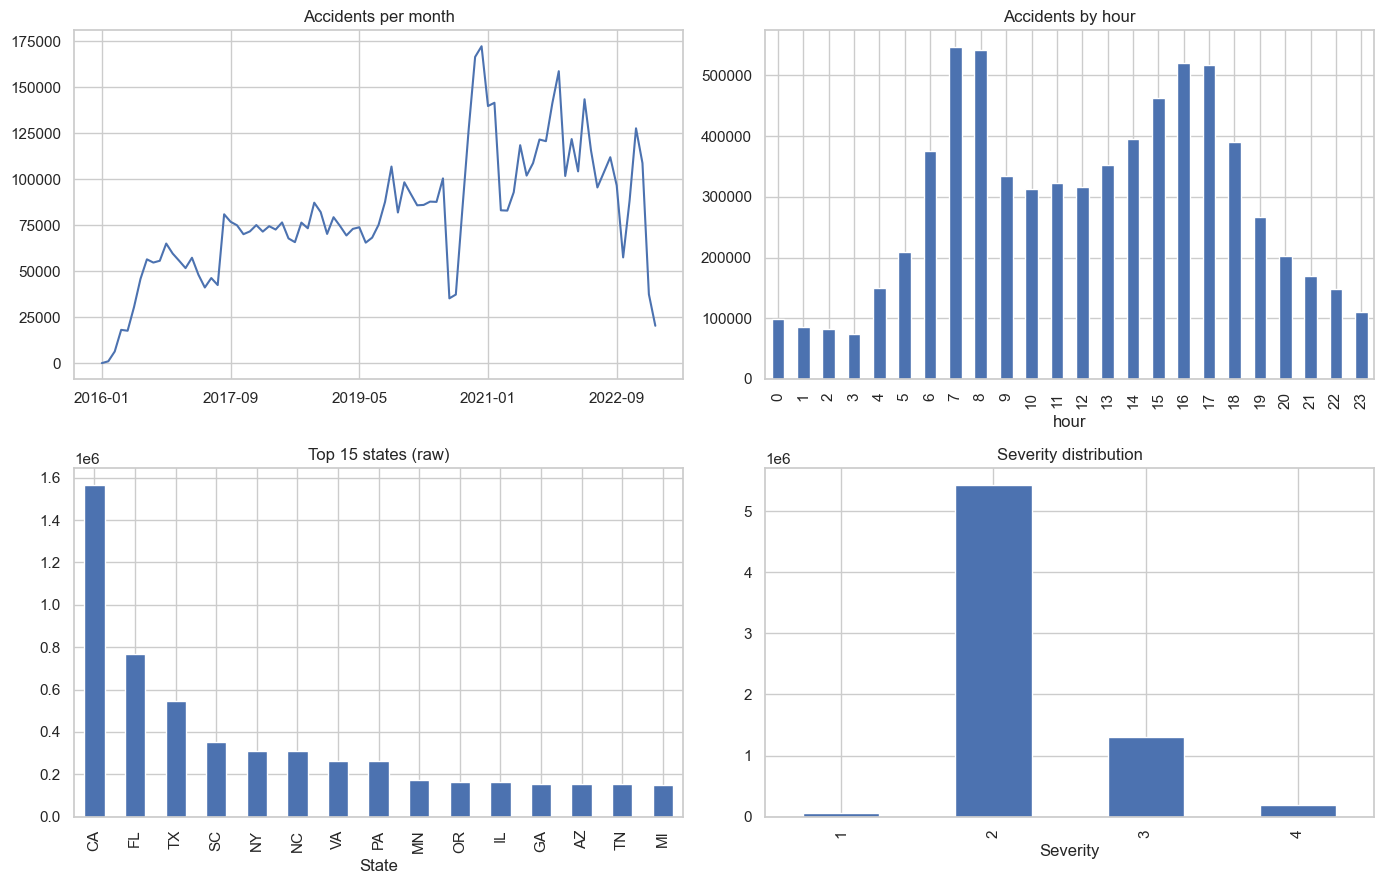

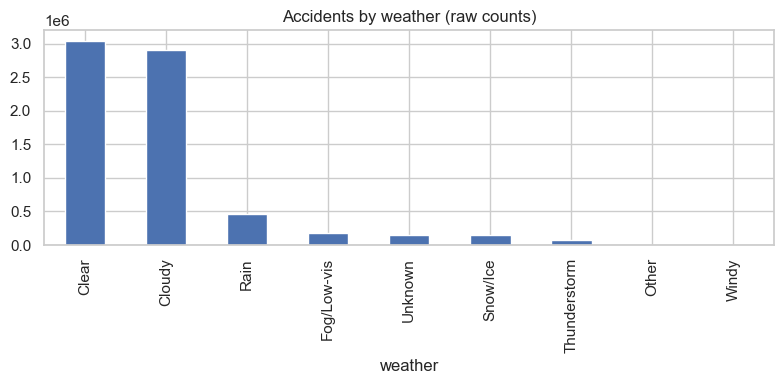

>> NOTE: raw counts peak in Clear/Cloudy because most driving happens in good weather. We therefore study SEVERITY (exposure-free) for the weather effect — next cell.


In [5]:
# 5. EDA
fig, ax = plt.subplots(2,2, figsize=(14,9))
df.groupby('ym').size().plot(ax=ax[0,0]); ax[0,0].set_title('Accidents per month'); ax[0,0].set_xlabel('')
df.groupby('hour').size().plot(kind='bar', ax=ax[0,1]); ax[0,1].set_title('Accidents by hour')
df['State'].value_counts().head(15).plot(kind='bar', ax=ax[1,0]); ax[1,0].set_title('Top 15 states (raw)')
df['Severity'].value_counts().sort_index().plot(kind='bar', ax=ax[1,1]); ax[1,1].set_title('Severity distribution')
plt.tight_layout(); plt.savefig('figs/eda_overview.png', dpi=120); plt.show()

plt.figure(figsize=(8,4)); df['weather'].value_counts().plot(kind='bar')
plt.title('Accidents by weather (raw counts)'); plt.tight_layout()
plt.savefig('figs/weather_counts.png', dpi=120); plt.show()
print(">> NOTE: raw counts peak in Clear/Cloudy because most driving happens in good weather. "
      "We therefore study SEVERITY (exposure-free) for the weather effect — next cell.")

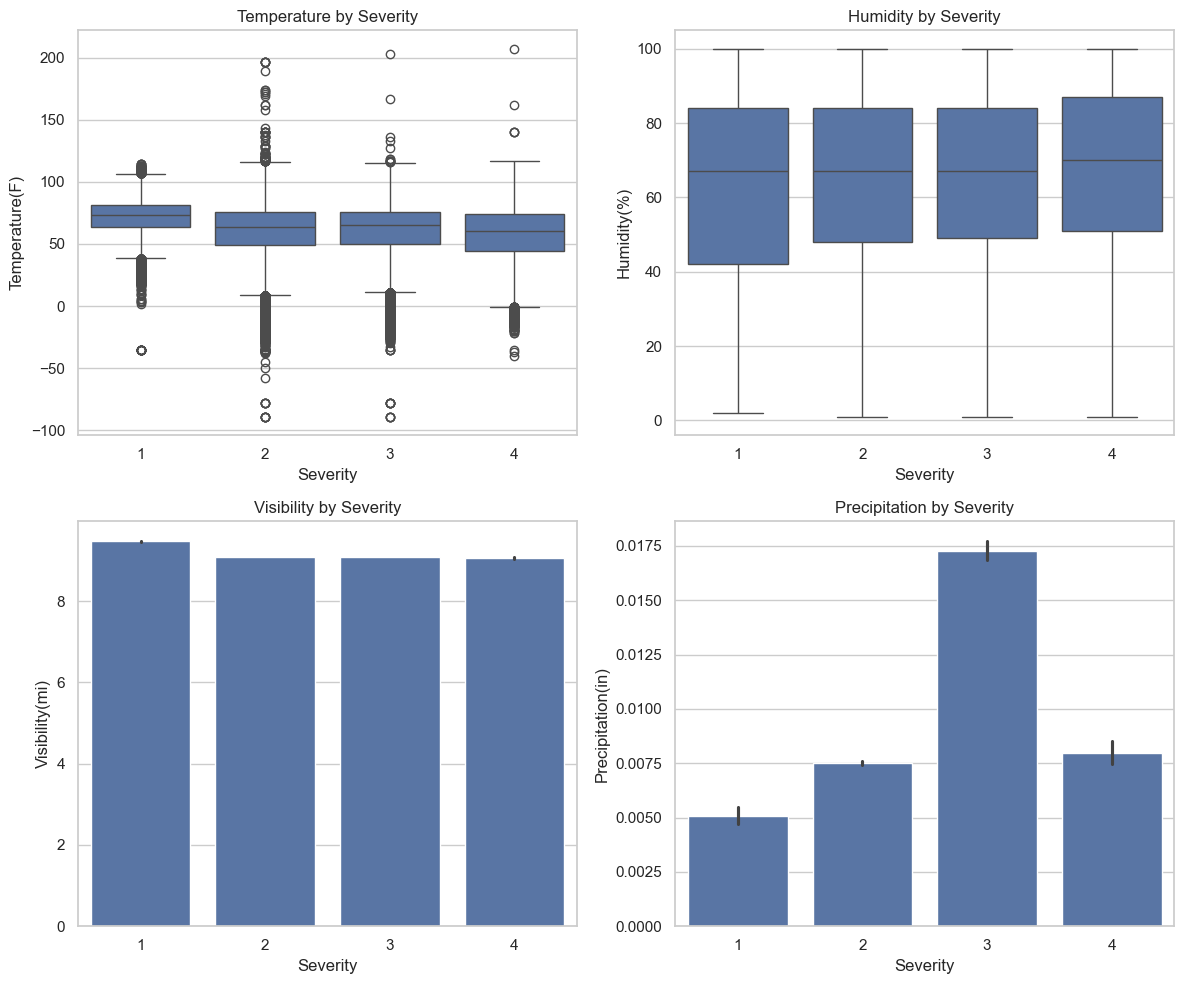

In [7]:
#6. Severity of crashes by weather condition

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

ax1 = sns.boxplot(data=df, x='Severity', y='Temperature(F)', ax=axes[0, 0])
ax1.set_title('Temperature by Severity')

ax2 = sns.boxplot(data=df, x='Severity', y='Humidity(%)', ax=axes[0, 1])
ax2.set_title('Humidity by Severity')

ax3 = sns.barplot(data=df, x='Severity', y='Visibility(mi)', ax=axes[1, 0])
ax3.set_title('Visibility by Severity')

ax4 = sns.barplot(data=df, x='Severity', y='Precipitation(in)', ax=axes[1, 1])
ax4.set_title('Precipitation by Severity')
	
plt.tight_layout()
plt.show()

               mean    count
weather                     
Rain          2.270   466748
Snow/Ice      2.265   155237
Cloudy        2.251  2899282
Thunderstorm  2.247    77545
Clear         2.200  3044607
Fog/Low-vis   2.192   182997


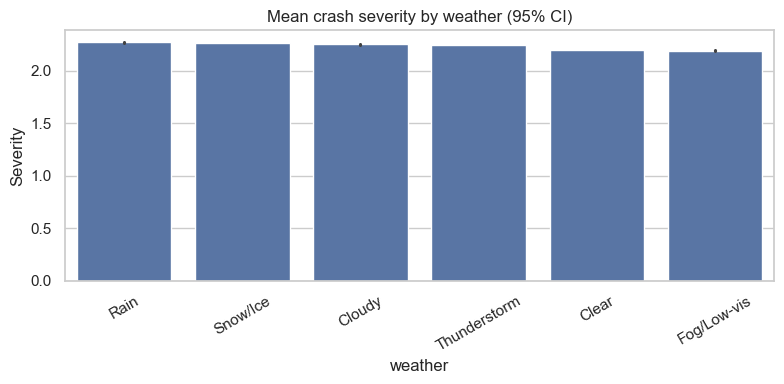

>> REPORT NUMBER chi2=32,916.0 dof=15 p=0.00e+00 CramersV=0.040 n=6,826,416
>> REPORT NUMBER Kruskal H=26,281.8 p=0.00e+00
>> REPORT NUMBER highest mean severity: Rain = 2.27


In [8]:
# 7. Statistical analysis: weather vs crash SEVERITY 
keep = ['Clear','Cloudy','Rain','Snow/Ice','Fog/Low-vis','Thunderstorm']
sub = df[df['weather'].isin(keep)].copy()

sev = sub.groupby('weather')['Severity'].agg(['mean','count']).sort_values('mean', ascending=False)
print(sev.round(3))
plt.figure(figsize=(8,4))
sns.barplot(data=sub, x='weather', y='Severity', errorbar=('ci',95), order=sev.index)
plt.title('Mean crash severity by weather (95% CI)'); plt.xticks(rotation=30)
plt.tight_layout(); plt.savefig('figs/severity_by_weather.png', dpi=120); plt.show()

ct = pd.crosstab(sub['weather'], sub['Severity'])
chi2, p, dof, _ = stats.chi2_contingency(ct)
n = ct.values.sum(); V = np.sqrt(chi2/(n*(min(ct.shape)-1)))
print(f">> REPORT NUMBER chi2={chi2:,.1f} dof={dof} p={p:.2e} CramersV={V:.3f} n={n:,}")
H, pk = stats.kruskal(*[g['Severity'].values for _,g in sub.groupby('weather')])
print(f">> REPORT NUMBER Kruskal H={H:,.1f} p={pk:.2e}")
print(">> REPORT NUMBER highest mean severity:", sev.index[0], "=", round(sev['mean'].iloc[0],3))

Text(0.5, 1.0, 'Mean crash severity by weather (y-axis zoomed to 2.15–2.29)')

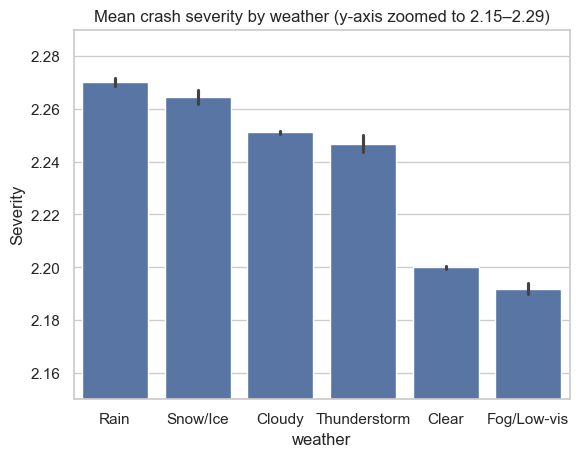

In [9]:
ax = sns.barplot(data=sub, x='weather', y='Severity', errorbar=('ci',95), order=sev.index)
ax.set_ylim(2.15, 2.29)   # zoom so the 0.08 spread is visible
plt.title('Mean crash severity by weather (y-axis zoomed to 2.15–2.29)')

In [10]:
# 8. Per-capita normalization by state + choropleth (fixes 'big states have more crashes')
state_pop = {'CA':38965000,'TX':30503000,'FL':22610000,'NY':19571000,'PA':12961000,'IL':12549000,
'OH':11785000,'GA':11029000,'NC':10835000,'MI':10037000,'NJ':9290000,'VA':8715000,'WA':7812000,
'AZ':7431000,'TN':7126000,'MA':7001000,'IN':6862000,'MO':6196000,'MD':6180000,'WI':5910000,
'CO':5877000,'MN':5737000,'SC':5373000,'AL':5108000,'LA':4574000,'KY':4526000,'OR':4233000,
'OK':4053000,'CT':3617000,'UT':3417000,'IA':3207000,'NV':3194000,'AR':3068000,'MS':2940000,
'KS':2941000,'NM':2114000,'NE':1978000,'ID':1965000,'WV':1770000,'HI':1435000,'NH':1402000,
'ME':1395000,'RI':1095000,'MT':1132000,'DE':1032000,'SD':919000,'ND':783000,'AK':733000,
'VT':647000,'WY':584000,'DC':678000}
region = {}
for r,sts in {'Northeast':'CT ME MA NH RI VT NJ NY PA','Midwest':'IL IN MI OH WI IA KS MN MO NE ND SD',
              'South':'DE FL GA MD NC SC VA DC WV AL KY MS TN AR LA OK TX',
              'West':'AZ CO ID MT NV NM UT WY AK CA HI OR WA'}.items():
    for s in sts.split(): region[s]=r

st = df.groupby('State').size().rename('accidents').reset_index()
st['pop'] = st['State'].map(state_pop); st = st.dropna(subset=['pop'])
st['per_100k'] = st['accidents']/st['pop']*1e5
st['region'] = st['State'].map(region)
print("Top 12 states by per-capita accident index:")
print(st.sort_values('per_100k', ascending=False).head(12)[['State','per_100k','region']].round(1).to_string(index=False))
print(">> REPORT NUMBER highest per-capita state:", st.sort_values('per_100k').iloc[-1]['State'])

try:
    import plotly.express as px
    fm = px.choropleth(st, locations='State', locationmode='USA-states', color='per_100k',
                       scope='usa', color_continuous_scale='OrRd',
                       title='Recorded accidents per 100k residents (relative index)')
    fm.write_html('figs/choropleth.html')
    try: fm.write_image('figs/choropleth.png', scale=2)
    except Exception as e: print('choropleth PNG skipped:', e)
    fm.show()
except Exception as e:
    print('choropleth skipped:', e)

Top 12 states by per-capita accident index:
State  per_100k  region
   SC    6533.3   South
   CA    4021.9    West
   OR    3846.2    West
   FL    3386.2   South
   VA    3002.2   South
   MN    2996.1 Midwest
   LA    2968.9   South
   NC    2859.9   South
   UT    2617.7    West
   DC    2323.9   South
   TN    2131.6   South
   AZ    2072.3    West
>> REPORT NUMBER highest per-capita state: SC


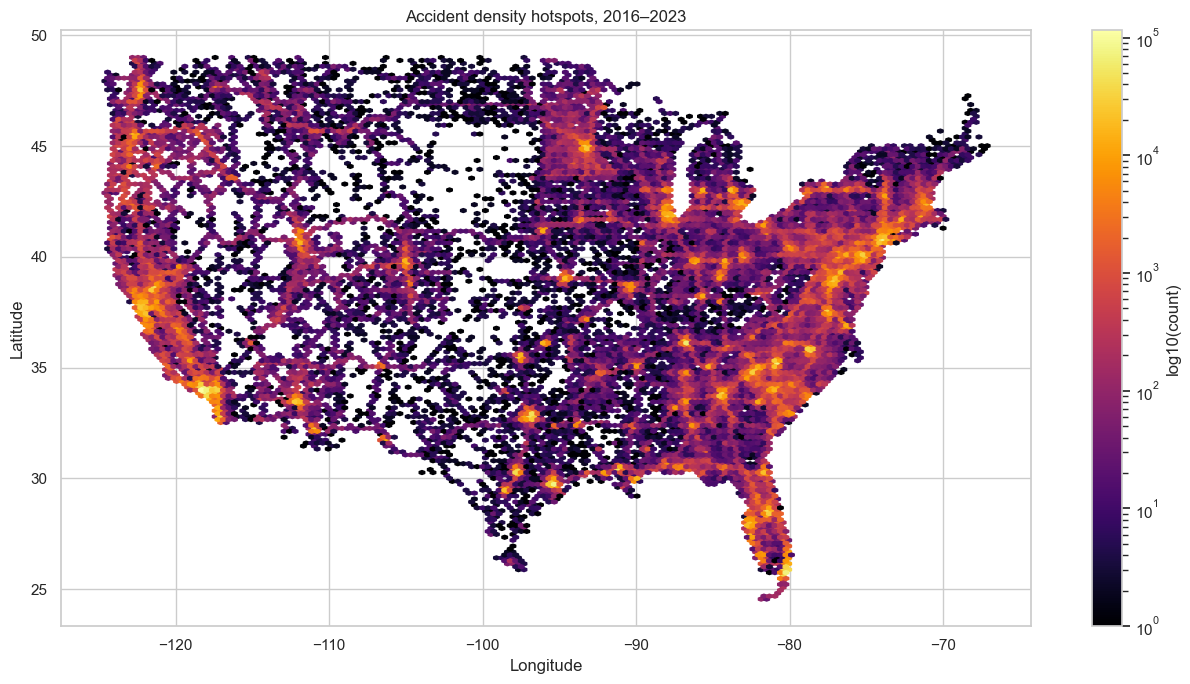

In [11]:
    # 9. Geospatial: accident density hotspots (continental US)
    m = df.dropna(subset=['Start_Lat','Start_Lng'])
    m = m[(m['Start_Lng']>-125)&(m['Start_Lng']<-66)&(m['Start_Lat']>24)&(m['Start_Lat']<50)]
    plt.figure(figsize=(13,7))
    hb = plt.hexbin(m['Start_Lng'], m['Start_Lat'], gridsize=160, cmap='inferno', mincnt=1, bins='log')
    plt.colorbar(hb, label='log10(count)'); plt.title('Accident density hotspots, 2016–2023')
    plt.xlabel('Longitude'); plt.ylabel('Latitude')
    plt.tight_layout(); plt.savefig('figs/density_hexbin.png', dpi=130); plt.show()

In [12]:
# 10. Predictive: monthly accident counts per state (exposure handled by log-pop offset)
panel = df.groupby(['State','year','month']).size().rename('count').reset_index()
panel = panel[panel['State'].isin(state_pop)]
panel['pop'] = panel['State'].map(state_pop)
panel['region'] = panel['State'].map(region)
panel['t'] = (panel['year']-panel['year'].min())*12 + panel['month']
cut = panel['t'].max()-6
train, test = panel[panel['t']<=cut].copy(), panel[panel['t']>cut].copy()

f = "count ~ C(month) + C(region)"
pois = smf.glm(f, data=train, family=sm.families.Poisson(), offset=np.log(train['pop'])).fit()
disp = pois.pearson_chi2/pois.df_resid
print(f">> REPORT NUMBER Poisson pseudoR2={1-pois.deviance/pois.null_deviance:.3f} dispersion={disp:.1f}")
nb = smf.glm(f, data=train, family=sm.families.NegativeBinomial(alpha=1.0), offset=np.log(train['pop'])).fit()
print(f">> REPORT NUMBER NegBin pseudoR2={1-nb.deviance/nb.null_deviance:.3f}")
for name,mod in [('Poisson',pois),('NegBin',nb)]:
    pred = mod.predict(test, offset=np.log(test['pop']))
    mae=np.mean(np.abs(pred-test['count'])); rmse=np.sqrt(np.mean((pred-test['count'])**2))
    print(f">> REPORT NUMBER {name} test MAE={mae:,.0f} RMSE={rmse:,.0f}")
irr = np.exp(pois.params.filter(like='C(month)'))
print(">> REPORT NUMBER peak-season month (highest IRR):", irr.idxmax(), "IRR=", round(irr.max(),2))

>> REPORT NUMBER Poisson pseudoR2=0.197 dispersion=954.0
>> REPORT NUMBER NegBin pseudoR2=0.085
>> REPORT NUMBER Poisson test MAE=1,201 RMSE=1,961
>> REPORT NUMBER NegBin test MAE=1,159 RMSE=2,291
>> REPORT NUMBER peak-season month (highest IRR): C(month)[T.12] IRR= 1.16


In [13]:
import pandas as pd
countypop_file = glob.glob('../data/USA_County_Population*.csv')[0]

countypop = pd.read_csv(countypop_file)
print(countypop.head())

                    county      2016      2017      2018      2019      2020  \
0  Autauga County, Alabama   41196.0   41527.0   41831.0   42175.0   42496.0   
1  Baldwin County, Alabama  155240.0  158361.0  162430.0  166595.0  171296.0   
2  Barbour County, Alabama   20879.0   20687.0   20346.0   20054.0   19804.0   
3     Bibb County, Alabama   17816.0   17852.0   17868.0   17862.0   17790.0   
4   Blount County, Alabama   44103.0   44102.0   44177.0   44292.0   44383.0   

       2021  
0   44438.0  
1  178105.0  
2   19995.0  
3   17800.0  
4   45201.0  


>> top 10 most accident prone counties (per 100k residents):
State           County  accidents  population    rate
   OR            Baker       3316     13166.0 25186.1
   SC          Calhoun       2278     11477.0 19848.4
   LA East Baton Rouge      69447    351168.0 19776.0
   OR            Union       3797     20438.0 18578.1
   OR            Wasco       3370     20649.0 16320.4
   NC      Mecklenburg     137330    842749.0 16295.5
   TN         Davidson      87836    561389.0 15646.2
   OR          Malheur       3604     23333.0 15445.9
   SC         Colleton       4594     29842.0 15394.4
   SC           Jasper       3466     22731.0 15247.9


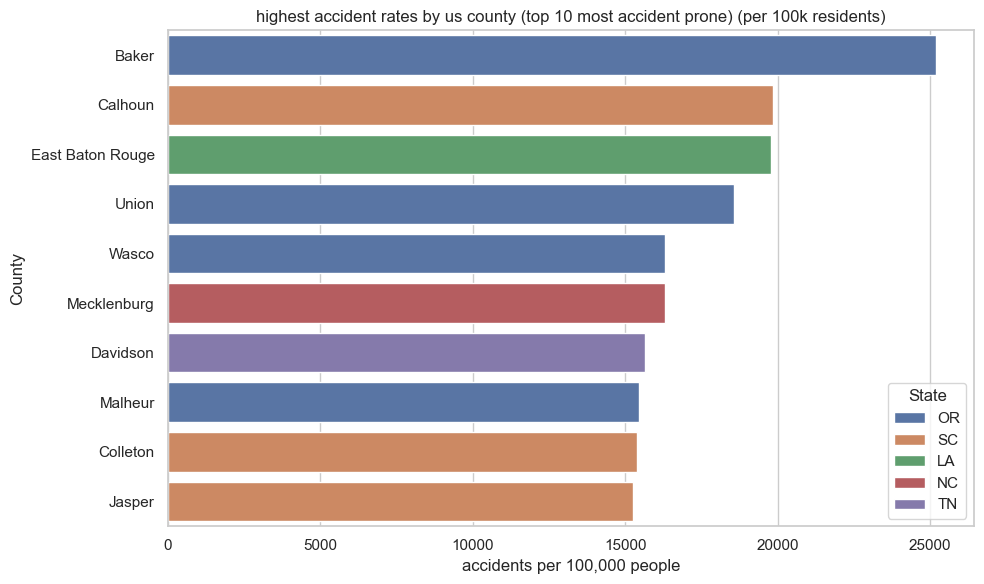

In [14]:
#11. analysis for accident rates by county level, for the 10 counties with most accidents

countypop[['County', 'State']] = countypop['county'].str.split(', ', expand=True)

countypop = countypop.rename(columns={'2021': 'population'})

statemap = {
    'Alabama': 'AL', 'Alaska': 'AK', 'Arizona': 'AZ', 'Arkansas': 'AR', 'California': 'CA',
    'Colorado': 'CO', 'Connecticut': 'CT', 'Delaware': 'DE', 'Florida': 'FL', 'Georgia': 'GA',
    'Hawaii': 'HI', 'Idaho': 'ID', 'Illinois': 'IL', 'Indiana': 'IN', 'Iowa': 'IA',
    'Kansas': 'KS', 'Kentucky': 'KY', 'Louisiana': 'LA', 'Maine': 'ME', 'Maryland': 'MD',
    'Massachusetts': 'MA', 'Michigan': 'MI', 'Minnesota': 'MN', 'Mississippi': 'MS', 'Missouri': 'MO',
    'Montana': 'MT', 'Nebraska': 'NE', 'Nevada': 'NV', 'New Hampshire': 'NH', 'New Jersey': 'NJ',
    'New Mexico': 'NM', 'New York': 'NY', 'North Carolina': 'NC', 'North Dakota': 'ND', 'Ohio': 'OH',
    'Oklahoma': 'OK', 'Oregon': 'OR', 'Pennsylvania': 'PA', 'Rhode Island': 'RI', 'South Carolina': 'SC',
    'South Dakota': 'SD', 'Tennessee': 'TN', 'Texas': 'TX', 'Utah': 'UT', 'Vermont': 'VT',
    'Virginia': 'VA', 'Washington': 'WA', 'West Virginia': 'WV', 'Wisconsin': 'WI', 'Wyoming': 'WY',
    'District of Columbia': 'DC'
}
countypop['State'] = countypop['State'].map(statemap)

countypop['County'] = countypop['County'].str.replace(' County', '', regex=False)
countypop['County'] = countypop['County'].str.replace(' Parish', '', regex=False)

countypop = countypop[['State', 'County', 'population']]

countycrashes = df.groupby(['State', 'County']).size().rename('accidents').reset_index()

mergedata = pd.merge(countycrashes, countypop, on=['State', 'County'], how='inner')

mergedata['rate'] = (mergedata['accidents'] / mergedata['population']) * 1e5

mergedata = mergedata[mergedata['population'] > 10000]

print(">> top 10 most accident prone counties (per 100k residents):")
topcounties = mergedata.sort_values('rate', ascending=False).head(10)
print(topcounties[['State', 'County', 'accidents', 'population', 'rate']].round(1).to_string(index=False))

plt.figure(figsize=(10, 6))
sns.barplot(data=topcounties, x='rate', y='County', hue='State', dodge=False)
plt.title('highest accident rates by us county (top 10 most accident prone) (per 100k residents)')
plt.xlabel('accidents per 100,000 people')
plt.tight_layout()
plt.savefig('figs/county_rates.png', dpi=120)
plt.show()


In [15]:
# 12. predictive analysis while taking into consideration, weather conditions
weatherpanel = df.groupby(['State', 'year', 'month', 'weather']).size().rename('count').reset_index()
weatherpanel = weatherpanel[weatherpanel['State'].isin(state_pop)]
weatherpanel['population'] = weatherpanel['State'].map(state_pop)
weatherpanel['region'] = weatherpanel['State'].map(region)

weatherpanel['time'] = (weatherpanel['year'] - weatherpanel['year'].min()) * 12 + weatherpanel['month']

timecut = weatherpanel['time'].max() - 6
traindata = weatherpanel[weatherpanel['time'] <= timecut].copy()
testdata = weatherpanel[weatherpanel['time'] > timecut].copy()

modelformula = "count ~ C(month) + C(region) + C(weather)"

negbinmodel = smf.glm(modelformula, data=traindata, family=sm.families.NegativeBinomial(alpha=1.0), offset=np.log(traindata['population'])).fit()

print(f">> negative binomial pseudor2 = {1 - negbinmodel.deviance / negbinmodel.null_deviance:.3f}")

weatherparams = np.exp(negbinmodel.params.filter(like='C(weather)'))
weatherparams.index = weatherparams.index.str.replace('C(weather)[T.', '').str.replace(']', '')

print("\n>> weather impact analysis (incidence rate ratios):")
print(weatherparams.sort_values(ascending=False).round(3).to_string())
print("\n*note: an irr greater than 1 indicates an increase in crash counts relative to baseline clear weather.")

>> negative binomial pseudor2 = 0.487

>> weather impact analysis (incidence rate ratios):
Cloudy          1.070
Snow/Ice        0.215
Rain            0.194
Unknown         0.083
Fog/Low-vis     0.065
Thunderstorm    0.051
Other           0.012
Windy           0.005

*note: an irr greater than 1 indicates an increase in crash counts relative to baseline clear weather.


In [16]:
# 13. Figures saved (download figs/ for the report)
# import os
# for f in sorted(os.listdir('figs')): print('figs/'+f)

In [17]:
# 14. linear regression for the severity of a crash based on the type of weather
weather_olsmodel = smf.ols(formula="Severity ~ weather", data=df).fit()

print(weather_olsmodel.summary())

                            OLS Regression Results                            
Dep. Variable:               Severity   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                  0.003
Method:                 Least Squares   F-statistic:                     2801.
Date:                Sun, 07 Jun 2026   Prob (F-statistic):               0.00
Time:                        05:05:01   Log-Likelihood:            -5.0428e+06
No. Observations:             6985228   AIC:                         1.009e+07
Df Residuals:                 6985219   BIC:                         1.009e+07
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 

In [18]:
# 15. linear regression for the severity of a crash based on the conditions
conditions_olsmodel = smf.ols(formula="Severity ~ Q('Temperature(F)') + Q('Humidity(%)') + Q('Precipitation(in)') + Q('Visibility(mi)')", data=df).fit()

print(weather_olsmodel.summary())

                            OLS Regression Results                            
Dep. Variable:               Severity   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                  0.003
Method:                 Least Squares   F-statistic:                     2801.
Date:                Sun, 07 Jun 2026   Prob (F-statistic):               0.00
Time:                        05:05:03   Log-Likelihood:            -5.0428e+06
No. Observations:             6985228   AIC:                         1.009e+07
Df Residuals:                 6985219   BIC:                         1.009e+07
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 